# EDA for home credit default risk

#### 1. Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import data_profiling
import matplotlib.pyplot as plt


from pathlib import Path
from data_profiling import ProfileReport


In [18]:
%matplotlib inline
# %pip uninstall -y ydata-profiling
# %pip install --upgrade --default-timeout=120 --retries 10 fg-data-profiling

#### 2. Загрузка данных:

In [2]:
path_to_data = "/home/usl/PycharmProjects/home-credit-default-risk/data/raw/home-credit-default-risk/"
# path_to_data = "/content/drive/MyDrive/Home_Credit_data/"

application_train_df = pd.read_csv(path_to_data+"application_train.csv")
application_test_df = pd.read_csv(path_to_data+"application_test.csv")
bureau_df = pd.read_csv(path_to_data+"bureau.csv")
bureau_balance_df = pd.read_csv(path_to_data+"bureau_balance.csv")
credit_card_balance_df = pd.read_csv(path_to_data+"credit_card_balance.csv")
home_credit_columns_description_df = pd.read_csv(path_to_data+"HomeCredit_columns_description.csv", encoding="cp1252")
installments_payments_df = pd.read_csv(path_to_data+"installments_payments.csv")
POS_CASH_balance_df = pd.read_csv(path_to_data+"POS_CASH_balance.csv")
previous_application_df = pd.read_csv(path_to_data+"previous_application.csv")
sample_submission_df = pd.read_csv(path_to_data+"sample_submission.csv")

#### 3. Размеры таблиц

In [3]:
size_tables = {
    "application_train": application_train_df,
    "application_test_df": application_test_df,
    "bureau": bureau_df,
    "bureau_balance": bureau_balance_df,
    "credit_card_balance": credit_card_balance_df,
    "home_credit_columns_description": home_credit_columns_description_df,
    "installments_payments": installments_payments_df,
    "POS_CASH_balance": POS_CASH_balance_df,
    "previous_application": previous_application_df,
    "sample_submission": sample_submission_df,
}

for name, df in size_tables.items():
    print(name, df.shape)

application_train (307511, 122)
application_test_df (48744, 121)
bureau (1716428, 17)
bureau_balance (27299925, 3)
credit_card_balance (3840312, 23)
home_credit_columns_description (219, 5)
installments_payments (13605401, 8)
POS_CASH_balance (10001358, 8)
previous_application (1670214, 37)
sample_submission (48744, 2)


#### 4. Проведем анализ данных основной таблицы application_train_df, используя ydata-profiling

In [4]:
profile = ProfileReport(application_train_df, minimal=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 122/122 [00:01<00:00, 74.87it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

#### 4. Исследование типов признаков

In [5]:
application_train_df.info(verbose=True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

In [8]:
application_train_df.dtypes.value_counts()
cat_col = application_train_df.select_dtypes(include = "object").columns.tolist()
num_col = application_train_df.select_dtypes(include = ["int64", "float64"]).columns.tolist()

В данных есть технические данные SK_ID_CURR, а также Target. После разделения данных на категориальные и числовые выведем 10 первых категориальных и 10 числовых признаков. Уберем из признаков технические данные.

In [9]:
num_features = [col for col in num_col if col not in ["TARGET", "SK_ID_CURR"]]

In [10]:
print("Категориальных признаков:", len(cat_col))
print("Числовых признаков:", len(num_features))
print()
print("Первые категориальные признаки:")
print(cat_col[:10])
print("Первые числовые признаки:")
print(num_col[:10])
print("Первые числовые признаки без технических данных:")
print(num_features[:10])

Категориальных признаков: 16
Числовых признаков: 104

Первые категориальные признаки:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
Первые числовые признаки:
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
Первые числовые признаки без технических данных:
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']


#### 5. Проверка идентификатора SK_ID_CURR текущей заявки в данных
Проверим уникальность и пересечение SK_ID_CURR в train, test. И подумаем, можно ли его считать обычным числовым признаком.

In [11]:
application_train_df["SK_ID_CURR"].is_unique

True

In [12]:
application_test_df["SK_ID_CURR"].is_unique

True

In [13]:
train_ids = set(application_train_df["SK_ID_CURR"])
test_ids = set(application_test_df["SK_ID_CURR"])
common_ids = train_ids.intersection(test_ids)
print("Общих ID между train и test:", len(common_ids))

Общих ID между train и test: 0


Значения являются уникальными, пересечений нет. Будем использовать идентификатор SK_ID_CURR для объединения таблиц. Как числовой признак не используется.
Также в application_train нет календарной даты заявки (число, месяц год), поэтому будем использовать деление выборки на train, validation случайным способом (hold-out).

#### 6. Работа с дубликатами
Посмотрим, есть полные дубликаты строк в train и test подвыборках:

In [14]:
print("Полных дубликатов строк в train", application_train_df.duplicated().sum())
print("Полных дубликатов строк в test", application_test_df.duplicated().sum())

Полных дубликатов строк в train 0
Полных дубликатов строк в test 0


Полных дубликатов строк нет, доп обработка не потребуется.

#### 7. Распределение классов в Target

In [15]:
target_count = application_train_df["TARGET"].value_counts().sort_index()
target_share = application_train_df["TARGET"].value_counts(normalize = True).sort_index()

print("Количество объектов:")
print(target_count)
print("Доли классов:")
print(target_share)

Количество объектов:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Доли классов:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


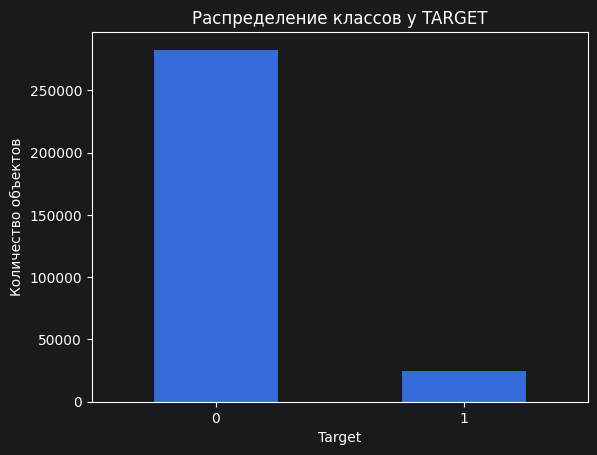

In [19]:
target_count.plot(kind = "bar")
plt.title("Распределение классов у TARGET")
plt.xlabel("Target")
plt.ylabel("Количество объектов")
plt.xticks(rotation = 0)
plt.show()


Виден сильный дисбаланс классов: класс 0 в 11 раз больше класса 1. Основной метрикой является ROC-AUC. Также будем смотреть Recall, Precision и Confusion Matrix. При делении application_train будем сохранять долю классов в train, validation выборках через параметр stratify = y.

#### 8. Работа с пропусками


In [20]:
application_train_df["DAYS_EMPLOYED"].value_counts().head(20)

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
-212         150
-384         143
-229         143
-231         140
-207         138
-215         138
-188         137
-216         137
-116         136
-196         136
-222         135
-193         134
-195         133
-214         132
-254         131
Name: count, dtype: int64

365243 - непонятно, что значит и что делать с этим?


In [21]:
missing_train = application_train_df.isna().mean() * 100
missing_table = pd.DataFrame({
    "missing_percent": missing_train,
    "dtype": application_train_df.dtypes.astype(str)
})

missing_table = missing_table.sort_values(
    "missing_percent",
    ascending=False
)
display(missing_table.head(30))

,missing_percent,dtype
COMMONAREA_AVG,69.872297,float64
COMMONAREA_MODE,69.872297,float64
COMMONAREA_MEDI,69.872297,float64
NONLIVINGAPARTMENTS_MEDI,69.432963,float64
NONLIVINGAPARTMENTS_MODE,69.432963,float64
NONLIVINGAPARTMENTS_AVG,69.432963,float64
FONDKAPREMONT_MODE,68.386172,object
LIVINGAPARTMENTS_AVG,68.354953,float64
LIVINGAPARTMENTS_MEDI,68.354953,float64
LIVINGAPARTMENTS_MODE,68.354953,float64


Как видно, самые большие пропуски имеют признаки, связанные с характеристикой жилья. Возможно, отсутствие информации также может характеризовать клиента.

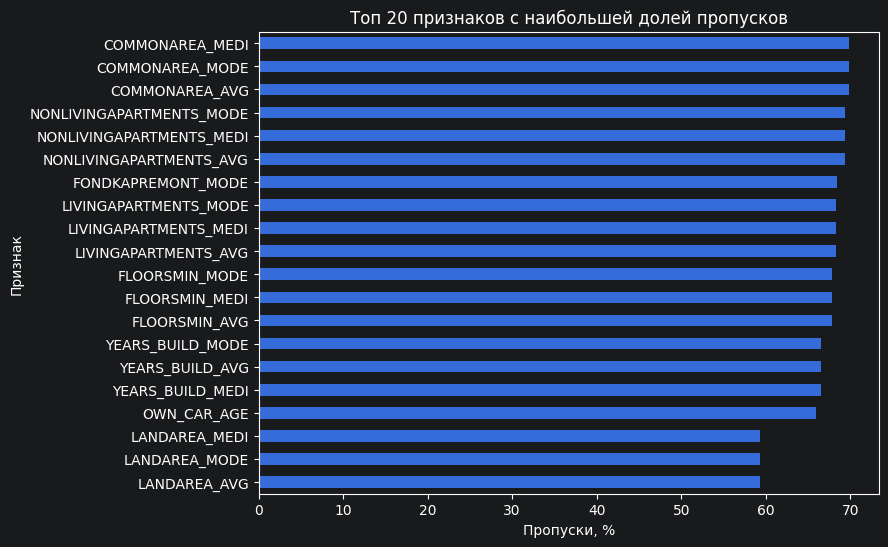

In [22]:
top_missing = missing_table.head(20).sort_values("missing_percent")

top_missing["missing_percent"].plot(kind = "barh", figsize=(8, 6))
plt.title("Топ 20 признаков с наибольшей долей пропусков")
plt.xlabel("Пропуски, %")
plt.ylabel("Признак")
plt.show()

In [23]:
feature_cols = [
    col for col in application_test_df.columns
    if col in application_train_df.columns
]

missing_compare = pd.DataFrame({
    "train_missing_percent":
        application_train_df[feature_cols].isna().mean() * 100,
    "test_missing_percent":
        application_test_df[feature_cols].isna().mean() * 100,
})

missing_compare["difference"] = (
    missing_compare["test_missing_percent"]
    - missing_compare["train_missing_percent"]
)

missing_compare["abs_difference"] = missing_compare["difference"].abs()

display(
    missing_compare.sort_values(
        "abs_difference",
        ascending=False
    ).head(20)
)

,train_missing_percent,test_missing_percent,difference,abs_difference
EXT_SOURCE_1,56.381073,42.122107,-14.258965,14.258965
EXT_SOURCE_3,19.825307,17.782701,-2.042606,2.042606
ENTRANCES_AVG,50.348768,48.373133,-1.975635,1.975635
ENTRANCES_MEDI,50.348768,48.373133,-1.975635,1.975635
ENTRANCES_MODE,50.348768,48.373133,-1.975635,1.975635
FLOORSMAX_MODE,49.760822,47.843837,-1.916984,1.916984
FLOORSMAX_MEDI,49.760822,47.843837,-1.916984,1.916984
FLOORSMAX_AVG,49.760822,47.843837,-1.916984,1.916984
YEARS_BEGINEXPLUATATION_AVG,48.781019,46.889874,-1.891146,1.891146
YEARS_BEGINEXPLUATATION_MEDI,48.781019,46.889874,-1.891146,1.891146


По структуре пропусков в train, test: выделяется сильно признак EXT_SOURCE_1. МЫ видим  дисбаланс значений в тренировочной и тестовой выборке.

#### 8.1 Связь пропусков с target
Проверим, отличается ли доля TARGET=1 между клиентами, у которых значение признака есть, и клиентами, у которых оно пропущено.

In [24]:
features_to_check = ["EXT_SOURCE_1", "OWN_CAR_AGE", "COMMONAREA_AVG", "YEARS_BUILD_AVG", "BASEMENTAREA_AVG"]

for col in features_to_check:
    missing_target = application_train_df.groupby(application_train_df[col].isna())["TARGET"].mean()

    print(col)
    print(missing_target)
    print()

EXT_SOURCE_1
EXT_SOURCE_1
False    0.074955
True     0.085195
Name: TARGET, dtype: float64

OWN_CAR_AGE
OWN_CAR_AGE
False    0.072441
True     0.085000
Name: TARGET, dtype: float64

COMMONAREA_AVG
COMMONAREA_AVG
False    0.069102
True     0.085742
Name: TARGET, dtype: float64

YEARS_BUILD_AVG
YEARS_BUILD_AVG
False    0.068664
True     0.086807
Name: TARGET, dtype: float64

BASEMENTAREA_AVG
BASEMENTAREA_AVG
False    0.068881
True     0.089128
Name: TARGET, dtype: float64



Для рассмотренных признаков доля TARGET=1 выше среди клиентов с пропущенными значениями, чем среди клиентов, у которых значение присутствует. Отсутствие значений может содержать полезный сигнал для модели. Поэтому для Random Forest при заполнении числовых пропусков медианой можно дополнительно сохранять индикатор пропуска. Для LightGBM числовые значения NaN можно оставить без явного заполнения.

#### 9. Работа с категориальными признаками
Для категориальных признаков проверяем:
- сколько уникальных категорий;
- есть ли пропуски;
- какая категория встречается чаще всего;
- есть ли редкие значения или выбросы.

In [29]:
cat_rows = []

for col in cat_col:
    counts = application_train_df[col].value_counts(dropna = False, normalize = True)

    cat_rows.append({
        "feature": col,
        "n_unique": application_train_df[col].nunique(dropna = True),
        "missing_percent": application_train_df[col].isna().mean() * 100,
        "most_common": counts.index[0],
        "most_common_share": counts.iloc[0] * 100,
    })

cat_summary = pd.DataFrame(cat_rows)

display(
    cat_summary.sort_values(
        "n_unique",
        ascending = False
    )
)

,feature,n_unique,missing_percent,most_common,most_common_share
11,ORGANIZATION_TYPE,58,0.000000,Business Entity Type 3,22.110429
9,OCCUPATION_TYPE,18,31.345545,NaN,31.345545
5,NAME_INCOME_TYPE,8,0.000000,Working,51.631974
4,NAME_TYPE_SUITE,7,0.420148,Unaccompanied,80.818572
14,WALLSMATERIAL_MODE,7,50.840783,NaN,50.840783
10,WEEKDAY_APPR_PROCESS_START,7,0.000000,TUESDAY,17.528153
7,NAME_FAMILY_STATUS,6,0.000000,Married,63.878040
8,NAME_HOUSING_TYPE,6,0.000000,House / apartment,88.734387
6,NAME_EDUCATION_TYPE,5,0.000000,Secondary / secondary special,71.018923
12,FONDKAPREMONT_MODE,4,68.386172,NaN,68.386172


ORGANIZATION_TYPE имеет 58 категорий и 0% пропусков, это самый большой категориальный признак.
OCCUPATION_TYPE имеет много пропусков, NaN имеет 18%.
Особенно много пропусков в признаках, связанных с жильём (FONDKAPREMONT_MODE, WALLSMATERIAL_MODE, HOUSETYPE_MODE, EMERGENCYSTATE_MODE), а также в OCCUPATION_TYPE.

In [31]:
cat_missing_features = ["OCCUPATION_TYPE", "FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE"]

for col in cat_missing_features:

    result = application_train_df.groupby(application_train_df[col].isna())["TARGET"].mean()

    print(col)
    print(result)
    print()

OCCUPATION_TYPE
OCCUPATION_TYPE
False    0.087851
True     0.065131
Name: TARGET, dtype: float64

FONDKAPREMONT_MODE
FONDKAPREMONT_MODE
False    0.068919
True     0.086188
Name: TARGET, dtype: float64

HOUSETYPE_MODE
HOUSETYPE_MODE
False    0.069870
True     0.091512
Name: TARGET, dtype: float64

WALLSMATERIAL_MODE
WALLSMATERIAL_MODE
False    0.069815
True     0.091281
Name: TARGET, dtype: float64

EMERGENCYSTATE_MODE
EMERGENCYSTATE_MODE
False    0.070025
True     0.092607
Name: TARGET, dtype: float64



Для большинства рассмотренных категориальных признаков наличие пропуска связано с изменением доли TARGET=1.
Для признаков, связанных с жильём (FONDKAPREMONT_MODE, HOUSETYPE_MODE, WALLSMATERIAL_MODE, EMERGENCYSTATE_MODE), доля проблемных клиентов выше среди строк с пропущенным значением.
OCCUPATION_TYPE показывает обратную зависимость: среди клиентов с пропущенным значением доля TARGET=1 ниже.

In [32]:
for col in ["ORGANIZATION_TYPE", "OCCUPATION_TYPE"]:

    print(col)

    counts = application_train_df[col].value_counts(dropna = False)

    print(counts.tail(10))
    print()

ORGANIZATION_TYPE
ORGANIZATION_TYPE
Legal Services       305
Cleaning             260
Transport: type 1    201
Industry: type 6     112
Industry: type 10    109
Religion              85
Industry: type 13     67
Trade: type 4         64
Trade: type 5         49
Industry: type 8      24
Name: count, dtype: int64

OCCUPATION_TYPE
OCCUPATION_TYPE
Security staff           6721
Cooking staff            5946
Cleaning staff           4653
Private service staff    2652
Low-skill Laborers       2093
Waiters/barmen staff     1348
Secretaries              1305
Realty agents             751
HR staff                  563
IT staff                  526
Name: count, dtype: int64



В ORGANIZATION_TYPE присутствуют очень редкие категории.

In [33]:
features = ["ORGANIZATION_TYPE", "OCCUPATION_TYPE"]

for col in features:
    result = (application_train_df.groupby(col, dropna = False)["TARGET"].agg(["count", "mean"]))

    result.columns = ["n_clients", "target_rate"]

    result = result.sort_values("target_rate", ascending = False)

    print(col)
    display(result)

ORGANIZATION_TYPE


,n_clients,target_rate
ORGANIZATION_TYPE,,
Transport: type 3,1187,0.157540
Industry: type 13,67,0.134328
Industry: type 8,24,0.125000
Restaurant,1811,0.117062
Construction,6721,0.116798
Cleaning,260,0.111538
Industry: type 1,1039,0.110683
Industry: type 3,3278,0.106162
Realtor,396,0.106061


OCCUPATION_TYPE


,n_clients,target_rate
OCCUPATION_TYPE,,
Low-skill Laborers,2093,0.171524
Drivers,18603,0.113261
Waiters/barmen staff,1348,0.112760
Security staff,6721,0.107424
Laborers,55186,0.105788
Cooking staff,5946,0.104440
Sales staff,32102,0.096318
Cleaning staff,4653,0.096067
Realty agents,751,0.078562


Категориальные признаки ORGANIZATION_TYPE и OCCUPATION_TYPE связаны с TARGET: доля проблемных клиентов различается между категориями.
Например, в OCCUPATION_TYPE доля TARGET=1 составляет 17.2% для Low-skill Laborers и около 4.8% для Accountants.
Необходимо применить smoothed target encoding для Random Forest.
Значение XNA в ORGANIZATION_TYPE встречается часто и имеет собственную долю TARGET=1, поэтому пока сохраняем его как отдельную категорию.

#### 10. Числовые признаки

In [34]:
application_train_df["CODE_GENDER"].value_counts(dropna = False)

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

XNA встречается 4 раза из 307 511 строк, это мало.

In [35]:
application_train_df["NAME_INCOME_TYPE"].value_counts(dropna = False)

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

Видим 4 большие категории и 4 редких категории.

In [36]:
(application_train_df.groupby("NAME_INCOME_TYPE")["TARGET"].agg(["count", "mean"]).sort_values("mean", ascending = False))

,count,mean
NAME_INCOME_TYPE,,
Maternity leave,5,0.400000
Unemployed,22,0.363636
Working,158774,0.095885
Commercial associate,71617,0.074843
State servant,21703,0.057550
Pensioner,55362,0.053864
Businessman,10,0.000000
Student,18,0.000000


Доля TARGET = 1 заметно отличается между крупными категориями NAME_INCOME_TYP: для Working она составляет 9,6%, для Commercial associate 7,5%, а для Pensioner 5,4%.

Рассмотрим признаки, связанные с деньгами

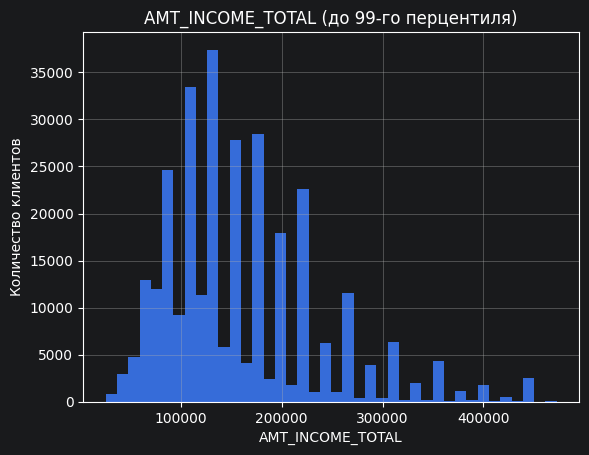

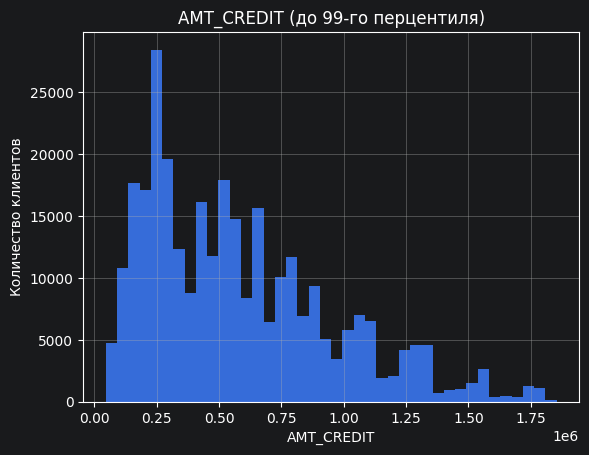

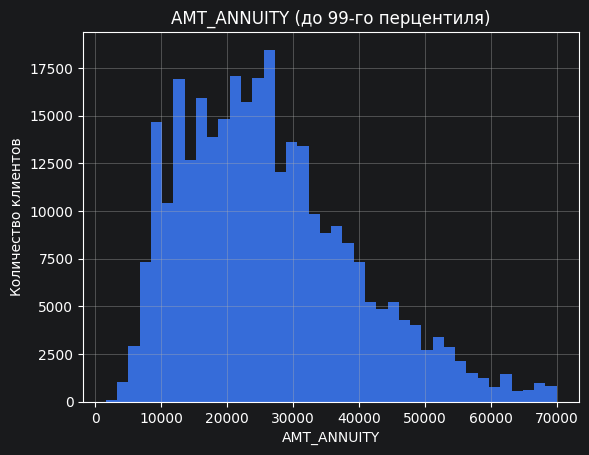

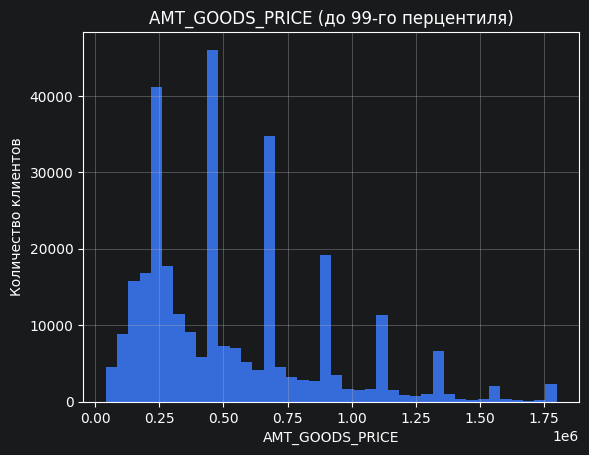

In [37]:
money_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

for col in money_features:
    values = application_train_df[col].dropna()
    upper = values.quantile(0.99)
    values_for_plot = values[values <= upper]
    values_for_plot.hist(bins=  40)

    plt.title(col + " (до 99-го перцентиля)")
    plt.xlabel(col)
    plt.ylabel("Количество клиентов")
    plt.show()

#### 11.Корреляция числовых признаков с Target

In [38]:
numeric_data = application_train_df.select_dtypes(include = ["int64", "float64"])
target_corr = (numeric_data.corr()["TARGET"].drop(["TARGET", "SK_ID_CURR"]))
top_corr_features = (target_corr.abs().sort_values(ascending = False).head(20).index)
top_corr = target_corr.loc[top_corr_features].sort_values()
display(top_corr)

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.155317
DAYS_EMPLOYED                 -0.044932
FLOORSMAX_AVG                 -0.044003
FLOORSMAX_MEDI                -0.043768
FLOORSMAX_MODE                -0.043226
AMT_GOODS_PRICE               -0.039645
REGION_POPULATION_RELATIVE    -0.037227
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64

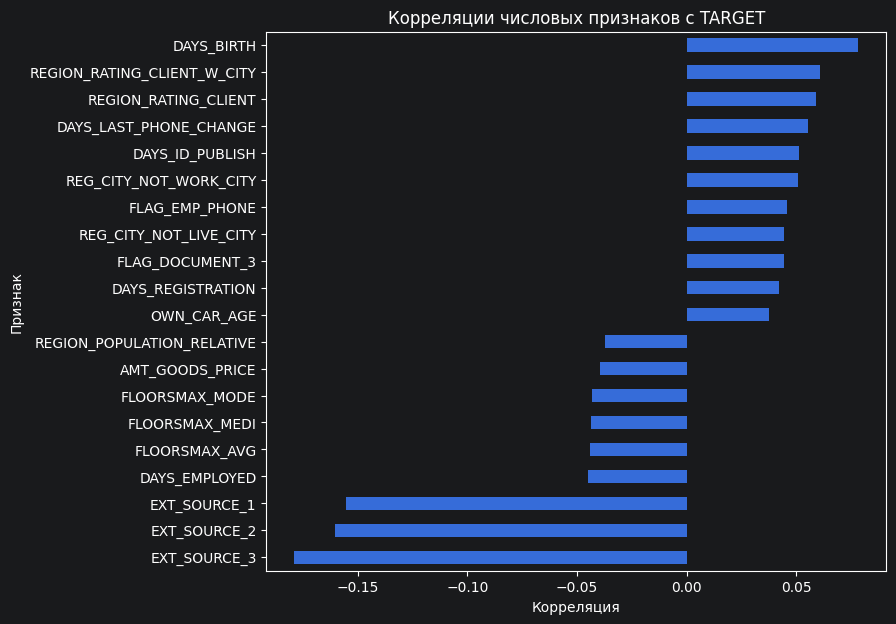

In [39]:
top_corr.plot(kind = "barh", figsize = (8, 7))

plt.title("Корреляции числовых признаков с TARGET")
plt.xlabel("Корреляция")
plt.ylabel("Признак")
plt.show()

#### 12. Константные значения

In [40]:
n_unique = application_train_df.nunique(dropna=False)

constant_features = n_unique[n_unique <= 1]

print("Количество константных признаков:",
      len(constant_features))

display(constant_features)

Количество константных признаков: 0


Series([], dtype: int64)

### Анализ других таблиц
Посмотрим SK_ID_CURR

In [41]:
bureau_df["SK_ID_CURR"].is_unique

False

In [42]:
bureau_df["SK_ID_BUREAU"].is_unique

True

In [43]:
bureau_df["SK_ID_CURR"].value_counts().describe()

count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
Name: count, dtype: float64

In [44]:
previous_application_df["SK_ID_CURR"].value_counts().describe()

count    338857.000000
mean          4.928964
std           4.220716
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          77.000000
Name: count, dtype: float64

In [45]:
bureau_balance_df["SK_ID_BUREAU"].value_counts().describe()

count    817395.000000
mean         33.398693
std          25.794666
min           1.000000
25%          13.000000
50%          26.000000
75%          48.000000
max          97.000000
Name: count, dtype: float64

In [46]:
train_ids = set(application_train_df["SK_ID_CURR"])
test_ids = set(application_test_df["SK_ID_CURR"])
common_ids = train_ids.intersection(test_ids)
print("Количество общих SK_ID_CURR:", len(common_ids))

Количество общих SK_ID_CURR: 0


In [47]:
application_train_df["SK_ID_CURR"].is_unique

True

In [48]:
application_test_df["SK_ID_CURR"].is_unique

True

In [49]:
application_train_df["SK_ID_CURR"].describe()

count    307511.000000
mean     278180.518577
std      102790.175348
min      100002.000000
25%      189145.500000
50%      278202.000000
75%      367142.500000
max      456255.000000
Name: SK_ID_CURR, dtype: float64

In [50]:
application_test_df["SK_ID_CURR"].describe()

count     48744.000000
mean     277796.676350
std      103169.547296
min      100001.000000
25%      188557.750000
50%      277549.000000
75%      367555.500000
max      456250.000000
Name: SK_ID_CURR, dtype: float64

Таким образом, в каждой таблице одна строка соответствует одной текущей заявке. Один текущий SK_ID_CURR встречается только 1 раз. То есть train и test занимают практически один и тот же диапазон SK_ID_CURR.

In [51]:
train_id_df = application_train_df[["SK_ID_CURR"]].copy()
train_id_df["dataset"] = "train"

test_id_df = application_test_df[["SK_ID_CURR"]].copy()
test_id_df["dataset"] = "test"

id_df = pd.concat([train_id_df, test_id_df], ignore_index = True)
id_df["id_bin"] = pd.qcut(id_df["SK_ID_CURR"], q = 10, duplicates="drop")
id_distribution = pd.crosstab(id_df["id_bin"], id_df["dataset"], normalize = "index")

id_distribution

dataset,test,train
id_bin,,
"(100000.999, 135626.4]",0.138382,0.861618
"(135626.4, 171251.8]",0.137067,0.862933
"(171251.8, 206877.2]",0.141049,0.858951
"(206877.2, 242502.6]",0.133698,0.866302
"(242502.6, 278128.0]",0.135772,0.864228
"(278128.0, 313753.4]",0.137572,0.862428
"(313753.4, 349378.8]",0.135439,0.864561
"(349378.8, 385004.2]",0.128417,0.871583
"(385004.2, 420629.6]",0.146554,0.853446


Вывод: SK_ID_CURR уникален внутри train и внутри test, при этом train и test не пересекаются, диапазоны SK_ID_CURR почти одинаковы. test распределен по всему диапазону SK_ID_CURR. Также SK_ID_CURR считаем техническим идентификатором, не будем проводить обучение моделей в качестве обычного числового признака.

Посмотрим другие таблицы, объединим application_train_df с bureau_df.

In [10]:
home_credit_columns_description_df.columns
home_credit_columns_description_df.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [5]:
bureau_df.info(verbose=True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   SK_ID_CURR              1716428 non-null  int64  
 1   SK_ID_BUREAU            1716428 non-null  int64  
 2   CREDIT_ACTIVE           1716428 non-null  object 
 3   CREDIT_CURRENCY         1716428 non-null  object 
 4   DAYS_CREDIT             1716428 non-null  int64  
 5   CREDIT_DAY_OVERDUE      1716428 non-null  int64  
 6   DAYS_CREDIT_ENDDATE     1610875 non-null  float64
 7   DAYS_ENDDATE_FACT       1082775 non-null  float64
 8   AMT_CREDIT_MAX_OVERDUE  591940 non-null   float64
 9   CNT_CREDIT_PROLONG      1716428 non-null  int64  
 10  AMT_CREDIT_SUM          1716415 non-null  float64
 11  AMT_CREDIT_SUM_DEBT     1458759 non-null  float64
 12  AMT_CREDIT_SUM_LIMIT    1124648 non-null  float64
 13  AMT_CREDIT_SUM_OVERDUE  1716428 non-null  float64
 14  CR

In [5]:
bureau_df = pd.read_csv(path_to_data+"bureau.csv")
bureau_df

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.0,0.0,0.0,Microloan,-19,NaN
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.0,0.0,0.0,Consumer credit,-2493,NaN
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.0,0.0,0.0,Consumer credit,-1508,NaN


In [8]:
application_bureau= application_train_df.merge(bureau_df, on = "SK_ID_CURR", how = "left", indicator = True)
application_bureau

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY_x,...,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY_y,_merge
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,0.0,40761.0,NaN,NaN,0.0,Credit card,-1038.0,0.0,both
1,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,0.0,0.0,0.00,NaN,0.0,Credit card,-47.0,NaN,both
2,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.000,0.0,135000.0,0.00,0.0,0.0,Consumer credit,-1185.0,0.0,both
3,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,3321.000,0.0,19071.0,NaN,NaN,0.0,Consumer credit,-906.0,0.0,both
4,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,5043.645,0.0,120735.0,0.00,0.0,0.0,Consumer credit,-34.0,0.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1509340,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0.000,0.0,436032.0,363573.54,0.0,0.0,Consumer credit,-25.0,0.0,both
1509341,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,15439.905,0.0,450000.0,191005.47,0.0,0.0,Consumer credit,-55.0,3244.5,both
1509342,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,25578.000,0.0,900000.0,NaN,NaN,0.0,Consumer credit,-781.0,0.0,both
1509343,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,2646.000,1.0,38925.0,NaN,NaN,0.0,Credit card,-779.0,3244.5,both


In [9]:
application_bureau._merge.value_counts()

_merge
both          1465325
left_only       44020
right_only          0
Name: count, dtype: int64